# Transfer Function Inversion (Staged Workflow)

Stages:
1. Configure inputs and load fit data
2. Estimate boundary-delay term with diagnostics
3. Run inversion with explicit time-shift compensation
4. Plot calibration, time-domain, spectra, and `H_inv` diagnostics

## Stage 1: Setup
Data loading

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def load_transfer_points(fit_details_path):
    """
    Load transfer function points from a single JSON file containing fit details.
    """
    payload = json.loads(Path(fit_details_path).read_text(encoding="utf-8"))
    param_index = {
        p.get("key"): i
        for i, p in enumerate(payload.get("parameters", []))
        if isinstance(p, dict) and p.get("key")
    }

    rows = []
    for entry in payload.get("batch_results", []):
        fit_results = entry.get("fit_results")
        params = fit_results.get("params")

        # H values
        freq = float(entry.get("captures").get("freq"))
        gain = float(params[param_index["A_mod"]])
        phase_pi = float(params[param_index["phi_delta"]])

        # time lag diagnostics - NB this needs careful consideration as it probably conflates with the phase lag?
        ch = fit_results.get("channel_results")
        ch3_b1 = float(ch.get("CH3").get("boundaries")[0])
        ch4_b1 = float(ch.get("CH4").get("boundaries")[0])
        delay_s = ch4_b1 - ch3_b1
        rows.append((freq, gain, phase_pi, ch3_b1, ch4_b1, delay_s))

    points = pd.DataFrame(
        rows,
        columns=[
            "freq_hz",
            "gain",
            "phase_pi",
            "ch3_boundary_1_s",
            "ch4_boundary_1_s",
            "boundary_delay_s",
        ],
    )
    if points.empty:
        raise ValueError(f"No valid fit points found in {fit_details_path}")
    return points.sort_values("freq_hz", ignore_index=True)


def load_transfer_table(
    fit_details_path, *, normalize_to_dc=True, aggregation_method="median"
):
    """
    Generate a transfer function calibration table from a JSON file containing fit details
        Optionally normalize gain to the DC (lowest frequency) reference.
        Remove duplicate frequency points by using some average (default is median) of their gain and phase values.
    """
    points = load_transfer_points(fit_details_path)
    # If we have duplicates take the median
    table = (
        points.groupby("freq_hz", as_index=False)
        .agg(
            gain=("gain", aggregation_method), phase_pi=("phase_pi", aggregation_method)
        )
        .sort_values("freq_hz", ignore_index=True)
    )

    if normalize_to_dc:
        dc_gain = float(table["gain"].iloc[0])
        if (not np.isfinite(dc_gain)) or dc_gain <= 0:
            raise ValueError("Cannot normalize gain with non-positive DC reference")
        table["gain"] = table["gain"] / dc_gain
        points = points.copy()
        points["gain"] = points["gain"] / dc_gain
    return table, points

dataset_files = {
    # "AFG": Path("../AFG_measurements/fit_details.json"),
    # "RedPitaya": Path("../RedPitaya_measurements/fit_details.json"),
    "RedPitaya": Path("../RedPitayaFixed_measurements/fit_details.json"),
}

dataset_data = {}
palette = ["tab:green", "tab:blue", "tab:orange", "tab:purple", "tab:brown", "tab:pink"]
for i, (name, fit_path) in enumerate(dataset_files.items()):
    transfer, raw_points = load_transfer_table(fit_path, normalize_to_dc=True)
    dataset_data[name] = {
        "transfer": transfer,
        "raw_points": raw_points,
        "color": palette[i % len(palette)],
    }
    print(f"{name}: {len(raw_points)} raw points, {len(transfer)} frequency bins")

RedPitaya: 194 raw points, 189 frequency bins


## Stage 2 - Delay Estimation
Estimates constant delay from `CH4_boundary_1 - CH3_boundary_1` with high-frequency weighting.
Diagnostic plot shows all points, selected fit subset, and estimated delay line.

NB: This cant necessarily just be shifted in the experiment as it conflates with the phase delay

RedPitaya: estimated delay (CH4-CH3) = -0.273 us, 


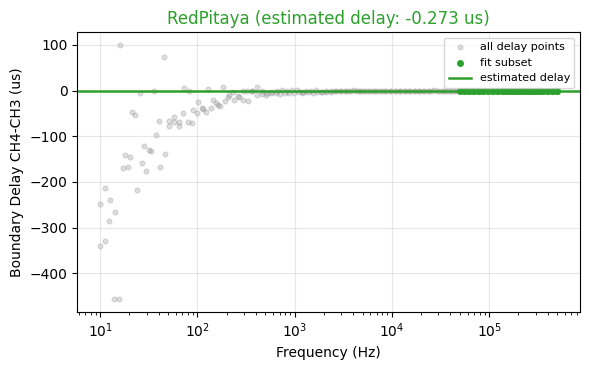

In [6]:
def _weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    v = values[order]
    w = weights[order]
    cum = np.cumsum(w)
    cutoff = 0.5 * np.sum(w)
    idx = int(np.searchsorted(cum, cutoff, side="left"))
    return float(v[min(idx, v.size - 1)])


def estimate_constant_boundary_delay(
    points, *, delay_col="boundary_delay_s", min_freq_hz=5e4, weight_power=1.0
):
    work = points[["freq_hz", delay_col]].dropna().copy()
    work = work[
        np.isfinite(work["freq_hz"])
        & np.isfinite(work[delay_col])
        & (work["freq_hz"] > 0)
    ]
    if work.empty:
        return 0.0, work
    hi = work[work["freq_hz"] >= float(min_freq_hz)]
    if len(hi) >= 5:
        work = hi
    freq = work["freq_hz"].to_numpy(dtype=float)
    delay = work[delay_col].to_numpy(dtype=float)
    scale = np.maximum(freq / np.max(freq), 1e-6)
    weights = scale ** float(weight_power)
    est = _weighted_median(delay, weights)
    return float(est), work

# Delay Estimation + Diagnostics
for col, (name, data) in enumerate(dataset_data.items()):
    fig = plt.figure(figsize=(6, 3.8))
    raw = data["raw_points"]
    est_delay_s, delay_samples = estimate_constant_boundary_delay(
        raw,
        min_freq_hz=5e4,
        weight_power=1.0,
    )
    data["estimated_delay_s"] = est_delay_s

    print(
        f"{name}: estimated delay (CH4-CH3) = {est_delay_s*1e6:+.3f} us, "
    )

    plt.scatter(raw["freq_hz"], raw["boundary_delay_s"] * 1e6, s=12, alpha=0.25, color="0.5", label="all delay points")
    plt.scatter(delay_samples["freq_hz"], delay_samples["boundary_delay_s"] * 1e6, s=16, color=data["color"], label="fit subset")
    plt.axhline(est_delay_s * 1e6, color=data["color"], linewidth=1.8, label="estimated delay")
    plt.xscale("log")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Boundary Delay CH4-CH3 (us)")
    plt.title(f"{name} (estimated delay: {est_delay_s*1e6:+.3f} us)", color=data["color"])
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Stage 3 - Inversion Run
Runs inversion using the configured transfer model

In [7]:
from scipy.signal import savgol_filter

def smooth(gain, phase, window_length=9, polyorder=2):
    gain_smooth = savgol_filter(gain, window_length=window_length, polyorder=polyorder)
    phase_smooth = savgol_filter(
        phase, window_length=window_length, polyorder=polyorder
    )
    return gain_smooth, phase_smooth

def smooth_curves(
    freq_hz,
    gain,
    phase,
    window_length: int = 15,
    polyorder: int = 2,
):
    """
    Smooth gain and phase curves and return callables on arbitrary frequency.
    Outside the provided range:
      - gain -> 1
      - phase -> 0
    """
    freq_hz = np.asarray(freq_hz, dtype=float)
    x = np.log10(freq_hz)

    gain_smooth, phase_smooth = smooth(
        gain, phase, window_length=window_length, polyorder=polyorder
    )

    def gain_fn(f):
        f = np.asarray(f, dtype=float)
        xf = np.log10(f)
        y = np.interp(xf, x, gain_smooth, left=1.0, right=1.0)
        return float(y) if np.ndim(f) == 0 else y

    def phase_fn(f):
        f = np.asarray(f, dtype=float)
        xf = np.log10(f)
        y = np.interp(xf, x, phase_smooth, left=0.0, right=0.0)
        return float(y) if np.ndim(f) == 0 else y

    return gain_fn, phase_fn


def invert(ts, desired_output, gain_fn, phase_fn):
    """
    Inversion using the smoothed curves
    """
    n = len(ts)
    freq_grid = np.fft.rfftfreq(n, d=float(np.median(np.diff(ts))))

    gain_interp = gain_fn(freq_grid)
    phase_interp = phase_fn(freq_grid)
    H = gain_interp * np.exp(1j * phase_interp)
    eps = 1e-12
    H_inv = np.conj(H) / (np.abs(H) ** 2 + eps**2)
    drive = np.fft.irfft(np.fft.rfft(desired_output) * H_inv, n=n)
    predicted_output = np.fft.irfft(np.fft.rfft(drive) * H, n=n)
    return drive, predicted_output


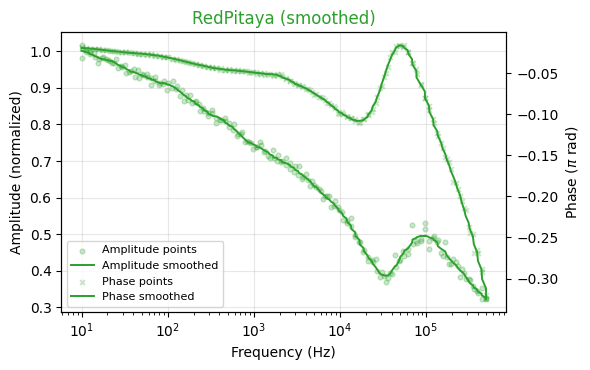

In [ ]:
for col, (name, data) in enumerate(dataset_data.items()):
    raw = data["raw_points"]
    transfer = data["transfer"]
    color = data["color"]
    freq_points = transfer["freq_hz"].to_numpy(float)
    gain_points = transfer["gain"].to_numpy(float)
    phase_points = np.pi * transfer["phase_pi"].to_numpy(float)  # convert to radians
    gain_smooth, phase_smooth = smooth_curves(freq_points, gain_points, phase_points)

    # Smoothed curves for better visualization and inversion
    line_freq = np.logspace(
        np.log10(freq_points.min()), np.log10(freq_points.max()), 400
    )

    fig = plt.figure(figsize=(6, 3.8), dpi=100)
    plt.scatter(
        raw["freq_hz"],
        raw["gain"],
        s=12,
        alpha=0.25,
        color=color,
        label="Amplitude points",
    )
    plt.xscale("log")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude (normalized)")
    plt.title(f"{name} (smoothed)", color=color)
    plt.grid(alpha=0.3)
    plt.plot(
        freq_points,
        gain_smooth(freq_points),
        color=color,
        linewidth=1.4,
        label="Amplitude smoothed",
    )

    h1, l1 = plt.gca().get_legend_handles_labels()

    axb = plt.twinx()
    axb.scatter(
        raw["freq_hz"],
        raw["phase_pi"],
        s=12,
        alpha=0.25,
        color=color,
        marker="x",
        label="Phase points",
    )
    axb.set_ylabel(r"Phase ($\pi$ rad)")
    axb.plot(
        freq_points,
        phase_smooth(freq_points) / np.pi,
        color=color,
        linewidth=1.4,
        label="Phase smoothed",
    )

    h2, l2 = axb.get_legend_handles_labels()
    plt.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()